<h1>1. Import Libraries</h1>

In [8]:
import h5py
import csv
import os
import sys
import tqdm
from matplotlib.colors import ListedColormap, to_rgb

import random
import numpy as np
import pandas as pd

import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

################## For training task ##################
import torch
import torchvision
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F

################## For Data task ##################
from torch.utils.data import DataLoader
from torchvision import transforms
import albumentations as A
from torchvision.transforms import InterpolationMode
from albumentations.pytorch import ToTensorV2

################## Import UNet from models ##################
PROJECT_DIR = '/kaggle/input/datasets/azurebob2/cityscapesegmentation/CityScapeSegmentation'
sys.path.insert(0, PROJECT_DIR)
from models import load_UNet, load_LightSeg

configs = {
    "project_name": "Multi task learning for Tumor Classification & Segmentation",
    "cityscape_path": '/kaggle/input/datasets/azurebob2/cityscapesegmentation/data',
    "cls_classes": 19,
    "image_size": 224,
    "n_channels": 3,
    "weight_saved_path":"/users/PGS0404/atran16/Desktop/CityScapeSegmentation/allTrainedResults/UnetCBAMMaxPool/UNet_CBAM_Cityscapes.pt",
}

test_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        #A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = {0: "road", 1: "sidewalk", 2: "building", 3: "wall", 4: "fence", 5: "pole", 
        6: "traffic light", 7: "traffic sign", 8: "vegetation", 9: "terrain", 10: "sky", 11: "person", 
        12: "rider", 13: "car", 14: "truck", 15: "bus", 16: "train", 17: "motorcycle", 18: "bicycle", 19: "others"}

color_mapping = {
    #Flat surfaces
    "road": "#666666", "sidewalk": "#282828",
    #Construction
    "building": "#FF3232", "wall" : "#6a329f", "fence": "#F110A6",
    #Objects / infrastructure
    "pole": "#523415", "traffic light": "#FFFF66", "traffic sign": "#FFFF00",
    #Nature
    "vegetation": "#008000", "terrain": "#6BAF6B",
    #Sky
    "sky": "#00b1ff",
    #Humans
    "person": "#E8BEAC", "rider": "#beace8",
    #Vehicle
    "car": "#FFA500", "truck": "#B07A15", "bus": "#101DCE", "train": "#3A2908", "motorcycle": "#E298D6", "bicycle": "#BEDFE5",
    #other:
    "others": "#E5ACB6"
}


colors = []
for i in sorted(classes.keys()):
    class_name = classes[i]
    colors.append(to_rgb(color_mapping[class_name]))

config_cmap = ListedColormap(colors)

<h1>2 Making segmentation</h1>

In [9]:
num_classes = configs['cls_classes'] + 1  # +1 for "others" class
trained_model = load_UNet(
    n_channels=configs['n_channels'],
    cls_classes=num_classes,
    pretrained_path=configs["weight_saved_path"],
    device=str(device),
    use_cbam=True
)
num_classes = configs['cls_classes'] + 1  # +1 for "others" class
# model = load_UNet(n_channels=configs['n_channels'], cls_classes=num_classes)

print(f"Model: UNet  |  Parameters: {sum(p.numel() for p in trained_model.parameters()):,}")
trained_model.to(device)
trained_model.eval()
print(f"trained weight loading successfully on device: {device}!")

CBAM Activated!
Loaded weights from '/users/PGS0404/atran16/Desktop/CityScapeSegmentation/allTrainedResults/UnetCBAMMaxPool/UNet_CBAM_Cityscapes.pt'
Model: UNet  |  Parameters: 31,055,802
trained weight loading successfully on device: cpu!


In [10]:
from utils.datasets import get_transforms
from utils.metrics import iou_score

val_tf = get_transforms(configs["image_size"], "val")

def _load_image(img_path):
    if img_path.endswith(".npy"):
        return np.load(img_path).astype(np.float32)
    bgr = cv2.imread(img_path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

def _mask_path_of(img_path):
    p = img_path.replace("/image/", "/label/")
    return p if p.endswith(".npy") else os.path.splitext(p)[0] + ".npy"

def makePredict(trained_model, img_path):
    """Mirror run_test_evaluation: jointly resize image & GT mask via val_tf, run model, return (transformed_image, gt_mask, pred_mask, (mean_iou, fw_iou))."""
    trained_model.eval()

    image = _load_image(img_path)
    mask  = np.load(_mask_path_of(img_path)).astype(np.int64)
    mask  = np.where(mask == -1, 19, mask)

    aug     = val_tf(image=image, mask=mask)
    t_image = aug["image"].unsqueeze(0).to(device)
    t_mask  = aug["mask"].long().unsqueeze(0).to(device)

    with torch.no_grad():
        output    = trained_model(t_image)
        pred_mask = torch.argmax(output, dim=1)

    m_iou, fw_iou, _ = iou_score(output, t_mask)
    return aug["image"], aug["mask"], pred_mask, (m_iou, fw_iou)

In [11]:
img_path = '/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/val/image/450.npy'
#img_path = '/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/val/image/480.npy'
#img_path = '/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/val/image/495.npy'

t_image, gt_mask, pred_mask, (m_iou, fw_iou) = makePredict(trained_model, img_path)
print(f"Mean IoU: {m_iou*100:.2f}%  |  FW IoU: {fw_iou*100:.2f}%")

Mean IoU: 50.72%  |  FW IoU: 90.44%


<h1>6.3 Visualizing testing images</h1>

In [12]:
def segmented_mask_visualize(t_image, gt_mask, pred_mask, m_iou, fw_iou):
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(t_image.permute(1, 2, 0))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Real mask (ground truth)")
    plt.imshow(gt_mask, cmap=config_cmap, vmin=0, vmax=19)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Prediction (IoU={m_iou*100:.2f}% | FW={fw_iou*100:.2f}%)")
    plt.imshow(pred_mask.squeeze(0).cpu().numpy(), cmap=config_cmap, vmin=0, vmax=19)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

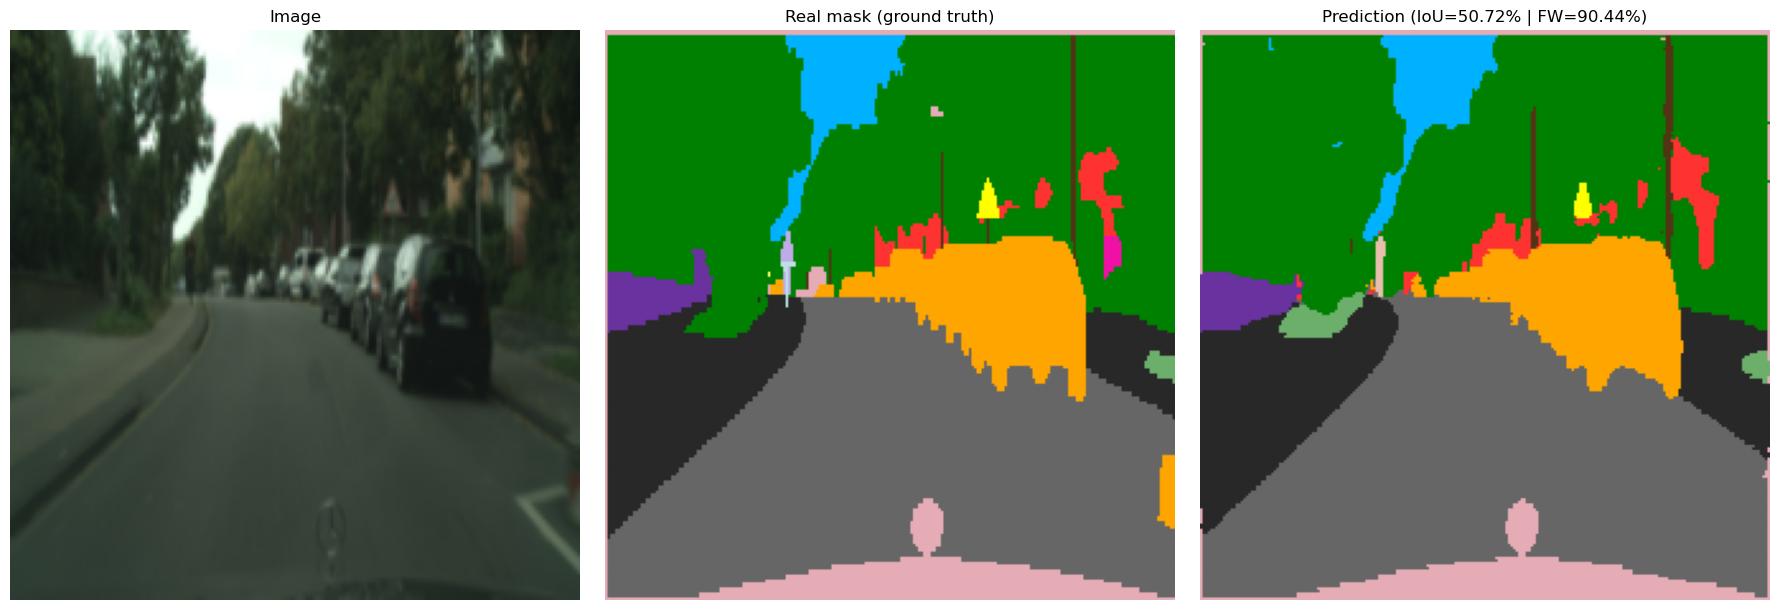

In [13]:
segmented_mask_visualize(t_image, gt_mask, pred_mask, m_iou, fw_iou)